In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    'primary'  : '#1A3A5C',
    'accent'   : '#E84855',
    'gold'     : '#F4A261',
    'green'    : '#2A9D8F',
    'light'    : '#E9ECEF',
    'mid'      : '#6C757D',
}
SURGE_COLORS = ['#2A9D8F','#57CC99','#F4A261','#E76F51','#E84855','#C1121F','#780000']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 120,
})

In [23]:
df = pd.read_csv("india_rideshare_dataset.csv")

In [24]:
df.head()

,trip_id,customer_id,customer_segment,loyalty_tier,city,source_zone,destination_zone,zone_type,cab_type,service_tier,...,temperature_c,apparent_temperature_c,humidity,wind_speed_kmh,precip_probability,precip_intensity,cloud_cover,visibility_km,weather_condition,cac_inr
0,TRIP_000001,CUST_00619,rare,Bronze,Delhi,Connaught Place,Rohini,commercial,Ola,Micro,...,39.1,38.3,0.55,3.9,0.33,0.0324,0.45,11.8,Heavy Rain,540.66
1,TRIP_000002,CUST_00485,occasional,Silver,Bangalore,HSR Layout,Marathahalli,residential,Ola,Mini,...,16.4,12.4,0.82,11.3,0.04,0.0107,0.12,13.0,Clear,337.57
2,TRIP_000003,CUST_01102,occasional,Silver,Delhi,Lajpat Nagar,Rohini,residential,Ola,Share,...,21.3,18.0,0.76,12.0,0.30,0.0190,0.41,10.5,Cloudy,326.06
3,TRIP_000004,CUST_00037,occasional,NaN,Mumbai,Powai,Dadar,residential,Uber,UberXL,...,32.7,32.6,0.64,16.9,0.35,0.0662,0.78,7.6,Humid,508.74
4,TRIP_000005,CUST_01864,occasional,NaN,Bangalore,Electronic City,HSR Layout,transit_hub,Ola,Mini,...,27.9,27.4,0.70,10.5,0.19,0.0043,0.82,13.6,Cloudy,432.51


In [25]:
df.shape

(50000, 41)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  50000 non-null  object 
 1   customer_id              50000 non-null  object 
 2   customer_segment         50000 non-null  object 
 3   loyalty_tier             31148 non-null  object 
 4   city                     50000 non-null  object 
 5   source_zone              50000 non-null  object 
 6   destination_zone         50000 non-null  object 
 7   zone_type                50000 non-null  object 
 8   cab_type                 50000 non-null  object 
 9   service_tier             50000 non-null  object 
 10  datetime                 50000 non-null  object 
 11  hour                     50000 non-null  int64  
 12  day                      50000 non-null  int64  
 13  month                    50000 non-null  int64  
 14  weekday               

In [27]:
df.describe()

,hour,day,month,is_peak_hour,is_weekend,latitude,longitude,distance_km,surge_multiplier,fare_inr,...,contribution_margin_inr,temperature_c,apparent_temperature_c,humidity,wind_speed_kmh,precip_probability,precip_intensity,cloud_cover,visibility_km,cac_inr
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.503460,15.67132,6.530260,0.292320,0.285900,19.095729,75.852458,8.483992,1.273190,192.493632,...,13.606306,27.983976,26.979244,0.675771,10.009190,0.299944,0.045131,0.500121,10.005872,374.774481
std,6.900775,8.74204,3.442249,0.454833,0.451847,6.151580,2.168128,6.863734,0.470438,156.848722,...,29.984068,5.993090,6.318076,0.158700,4.626323,0.173602,0.039874,0.230854,3.470041,90.396409
min,0.000000,1.00000,1.000000,0.000000,0.000000,12.870000,72.780000,1.500000,1.000000,30.820000,...,-20.820000,3.600000,0.700000,0.400000,2.000000,0.000000,0.000000,0.100000,4.000000,162.560000
25%,6.000000,8.00000,4.000000,0.000000,0.000000,12.997500,72.972800,3.520000,1.000000,94.540000,...,-4.910000,24.000000,22.700000,0.540000,6.000000,0.150000,0.012100,0.300000,7.000000,306.670000
50%,12.000000,16.00000,7.000000,0.000000,0.000000,19.004250,77.184100,6.340000,1.000000,142.880000,...,4.370000,28.000000,27.000000,0.680000,10.000000,0.300000,0.033700,0.500000,10.000000,388.840000
75%,17.000000,23.00000,10.000000,1.000000,1.000000,28.456000,77.590900,11.190000,1.500000,232.112500,...,21.462500,32.000000,31.200000,0.810000,14.000000,0.450000,0.068900,0.700000,13.000000,440.890000
max,23.000000,31.00000,12.000000,1.000000,1.000000,28.750000,77.750000,40.000000,2.500000,2112.470000,...,366.500000,55.700000,55.000000,0.950000,18.000000,0.600000,0.179800,0.900000,16.000000,710.030000


In [28]:
df.isnull().sum()

trip_id                        0
customer_id                    0
customer_segment               0
loyalty_tier               18852
city                           0
source_zone                    0
destination_zone               0
zone_type                      0
cab_type                       0
service_tier                   0
datetime                       0
hour                           0
day                            0
month                          0
weekday                        0
is_peak_hour                   0
is_weekend                     0
latitude                       0
longitude                      0
distance_km                    0
surge_multiplier               0
fare_inr                       0
ride_completed                 0
satisfaction_score             0
days_since_last_ride           0
churn_risk_flag                0
driver_payout_inr              0
platform_revenue_inr           0
platform_take_rate             0
cost_per_trip_inr              0
contributi

In [29]:
df['loyalty_tier'] = df['loyalty_tier'].fillna('No Loyalty')

In [30]:
df['loyalty_tier'].value_counts(dropna=False)

loyalty_tier
No Loyalty    18852
Bronze        16092
Silver        10095
Gold           4961
Name: count, dtype: int64

In [31]:
SURGE_ORDER = ['1.0x','1.25x','1.50x','1.75x','2.00x','2.25x','2.50x']
SURGE_MAP   = {1.0:'1.0x',1.25:'1.25x',1.5:'1.50x',
               1.75:'1.75x',2.0:'2.00x',2.25:'2.25x',2.5:'2.50x'}
df['surge_band']   = df['surge_multiplier'].map(SURGE_MAP)
df['time_segment'] = df['is_peak_hour'].map({1:'Peak', 0:'Off-Peak'})
df['day_type']     = df['is_weekend'].map({1:'Weekend', 0:'Weekday'})
df['cancelled']    = 1 - df['ride_completed']

print('Surge distribution:')
print(df['surge_band'].value_counts().reindex(SURGE_ORDER))

Surge distribution:
surge_band
1.0x     34381
1.25x     2573
1.50x     2665
1.75x     2630
2.00x     2542
2.25x     2577
2.50x     2632
Name: count, dtype: int64


## Workstream 1 - Demand Suppression & Customer Response Analysis

Business question: At which surge levels and in which city/zone/time combinations does pricing-driven behavioral deterioration become measurable?

Methodology: Compare four customer-behavioral metrics across surge bands, controlling for time-of-day (peak/off-peak) as a demand proxy. A pricing-driven deterioration is flagged when a metric changes materially relative to the no-surge (1.0x) baseline under comparable time conditions.

Metrics tracked: Completion rate · Cancellation rate · Satisfaction score · Churn risk flag rate

In [32]:
metrics_surge = (
    df.groupby('surge_band')
      .agg(
          n_trips           = ('trip_id','count'),
          completion_rate   = ('ride_completed','mean'),
          cancellation_rate = ('cancelled','mean'),
          avg_satisfaction  = ('satisfaction_score','mean'),
          churn_risk_rate   = ('churn_risk_flag','mean'),
      )
      .reindex(SURGE_ORDER)
      .reset_index()
)
print('Table 1 -- Behavioural Metrics by Surge Band')
print(metrics_surge.to_string(index=False, float_format='%.4f'))

Table 1 -- Behavioural Metrics by Surge Band
surge_band  n_trips  completion_rate  cancellation_rate  avg_satisfaction  churn_risk_rate
      1.0x    34381           1.0000             0.0000            4.1373           0.0120
     1.25x     2573           0.9596             0.0404            3.8204           0.0093
     1.50x     2665           0.9036             0.0964            3.4883           0.0124
     1.75x     2630           0.9133             0.0867            3.1789           0.0114
     2.00x     2542           0.8155             0.1845            2.8185           0.0122
     2.25x     2577           0.8207             0.1793            2.5056           0.0159
     2.50x     2632           0.8191             0.1809            2.2222           0.0148


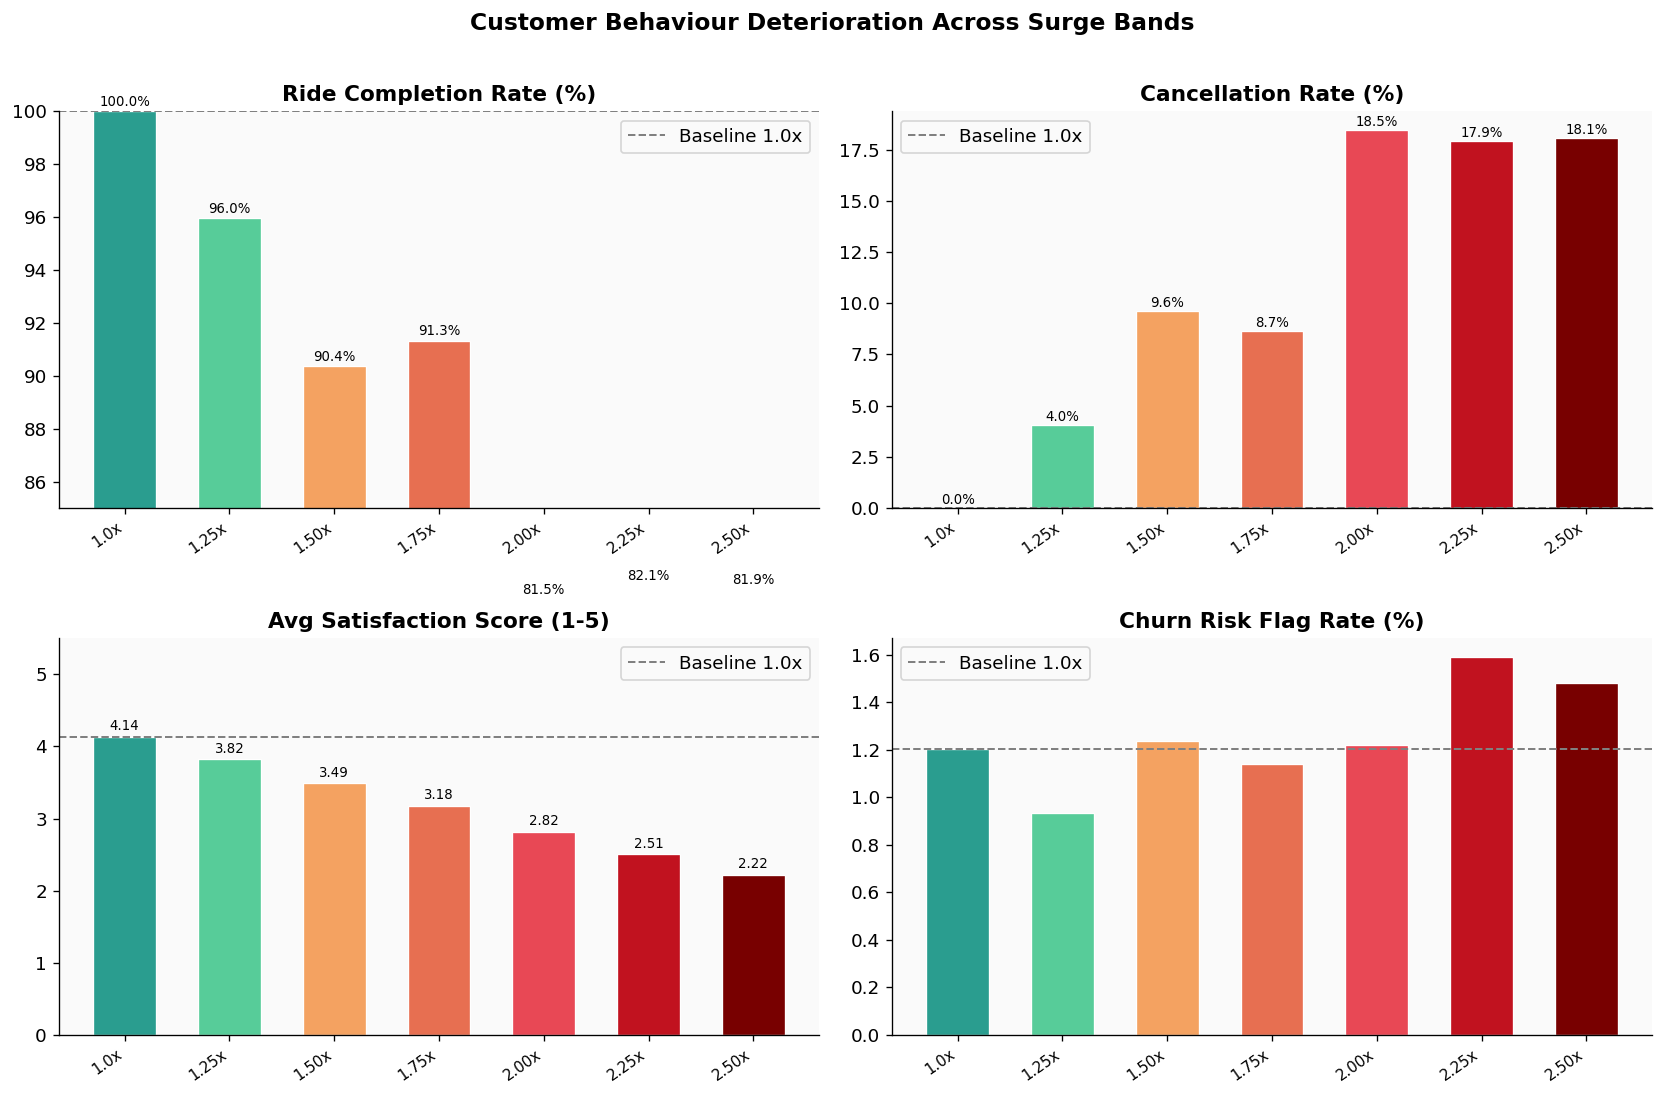

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Customer Behaviour Deterioration Across Surge Bands',
             fontsize=14, fontweight='bold', y=1.01)

x = np.arange(len(SURGE_ORDER))
bkw = dict(width=0.6, edgecolor='white', linewidth=0.8)

ax = axes[0,0]
bars = ax.bar(x, metrics_surge['completion_rate']*100, color=SURGE_COLORS, **bkw)
ax.set_title('Ride Completion Rate (%)'); ax.set_xticks(x)
ax.set_xticklabels(SURGE_ORDER, rotation=35, ha='right', fontsize=9)
ax.set_ylim(85,100)
ax.axhline(metrics_surge.iloc[0]['completion_rate']*100, ls='--', color='grey', lw=1.2, label='Baseline 1.0x')
ax.legend()
for bar,v in zip(bars,metrics_surge['completion_rate']): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax = axes[0,1]
bars = ax.bar(x, metrics_surge['cancellation_rate']*100, color=SURGE_COLORS, **bkw)
ax.set_title('Cancellation Rate (%)'); ax.set_xticks(x)
ax.set_xticklabels(SURGE_ORDER, rotation=35, ha='right', fontsize=9)
ax.axhline(metrics_surge.iloc[0]['cancellation_rate']*100, ls='--', color='grey', lw=1.2, label='Baseline 1.0x')
ax.legend()
for bar,v in zip(bars,metrics_surge['cancellation_rate']): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax = axes[1,0]
bars = ax.bar(x, metrics_surge['avg_satisfaction'], color=SURGE_COLORS, **bkw)
ax.set_title('Avg Satisfaction Score (1-5)'); ax.set_xticks(x)
ax.set_xticklabels(SURGE_ORDER, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0,5.5)
ax.axhline(metrics_surge.iloc[0]['avg_satisfaction'], ls='--', color='grey', lw=1.2, label='Baseline 1.0x')
ax.legend()
for bar,v in zip(bars,metrics_surge['avg_satisfaction']): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax = axes[1,1]
bars = ax.bar(x, metrics_surge['churn_risk_rate']*100, color=SURGE_COLORS, **bkw)
ax.set_title('Churn Risk Flag Rate (%)'); ax.set_xticks(x)
ax.set_xticklabels(SURGE_ORDER, rotation=35, ha='right', fontsize=9)
ax.axhline(metrics_surge.iloc[0]['churn_risk_rate']*100, ls='--', color='grey', lw=1.2, label='Baseline 1.0x')
ax.legend()

plt.tight_layout()
plt.savefig('fig1_behaviour_surge.png', bbox_inches='tight', dpi=150)
plt.show()


### Business Interpretation

Customer behaviour deteriorates progressively as surge intensity increases across all key service metrics.

Ride completion rates decline materially beyond the 1.5x–1.75x surge range, indicating increasing customer resistance to elevated pricing levels.

Cancellation rates rise sharply under high and extreme surge conditions, increasing from near-zero levels at baseline pricing to nearly 18% at 2.0x+ surge levels.

Average customer satisfaction scores decline consistently with higher surge multipliers, suggesting erosion of customer trust and perceived service fairness.

Churn risk indicators also increase at aggressive surge levels, implying that short-term revenue gains may negatively impact long-term customer retention and platform loyalty.

Overall, the analysis suggests that excessive surge pricing creates measurable behavioural deterioration and may reduce the sustainability of long-term growth.

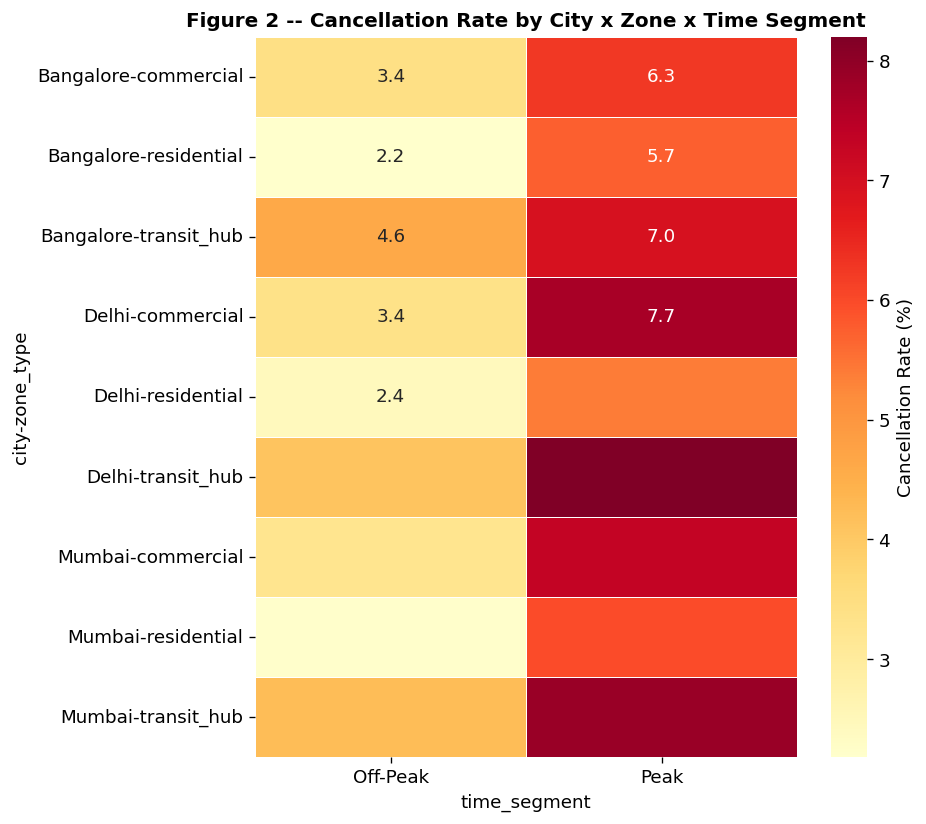

In [34]:
pivot = (
    df.groupby(['city','zone_type','time_segment'])
      .agg(cancel_rate=('cancelled','mean'))
      .reset_index()
)
pivot_wide = pivot.pivot_table(
    index=['city','zone_type'], columns='time_segment', values='cancel_rate') * 100

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot_wide, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Cancellation Rate (%)'})
ax.set_title('Figure 2 -- Cancellation Rate by City x Zone x Time Segment',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_heatmap_cancellation.png', bbox_inches='tight', dpi=150)
plt.show()


### Business Interpretation

Cancellation rates increase significantly during peak periods across all cities and zone types.

Transit hubs show the highest cancellation levels, especially in Delhi and Mumbai during peak hours.

Residential zones remain relatively stable during off-peak periods but show noticeable deterioration during demand spikes.

The findings suggest that pricing sensitivity varies across operational conditions, supporting the need for zone-specific surge strategies.

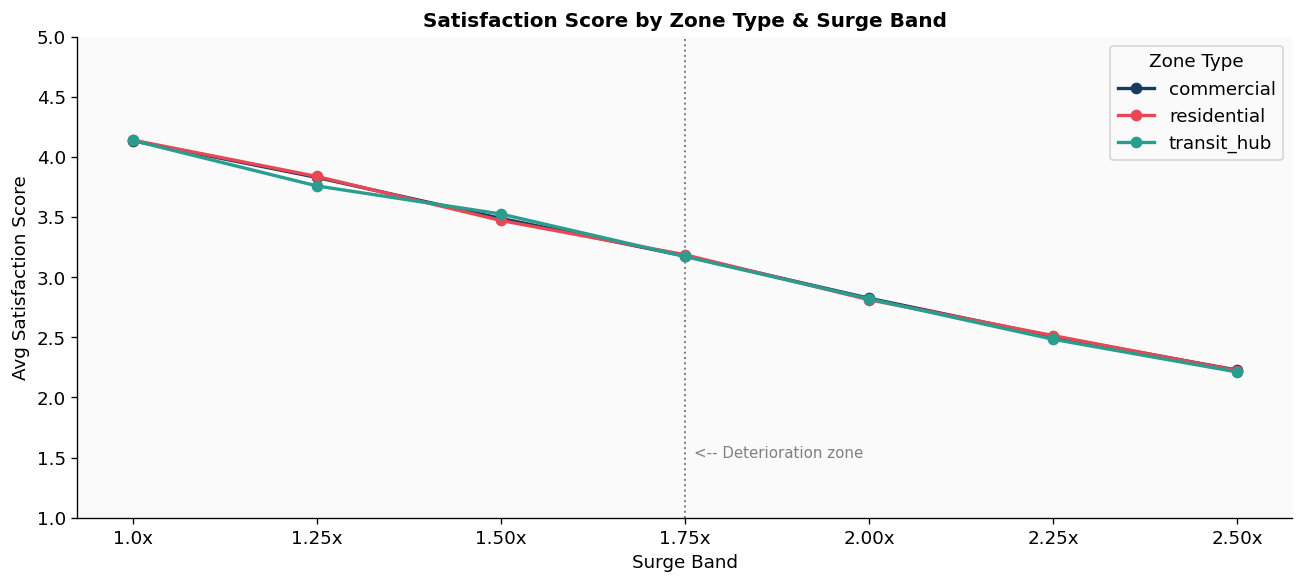

In [35]:
sat_zone = (
    df.groupby(['zone_type','surge_band'])['satisfaction_score']
      .mean().reset_index()
      .pivot(index='zone_type', columns='surge_band', values='satisfaction_score')
      .reindex(columns=SURGE_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 5))
zone_cols = [PALETTE['primary'], PALETTE['accent'], PALETTE['green']]
for i, zone in enumerate(sat_zone.index):
    ax.plot(SURGE_ORDER, sat_zone.loc[zone], marker='o',
            color=zone_cols[i], linewidth=2, label=zone)
ax.set_title('Satisfaction Score by Zone Type & Surge Band',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Surge Band'); ax.set_ylabel('Avg Satisfaction Score')
ax.set_ylim(1, 5); ax.legend(title='Zone Type')
ax.axvline(x=3, ls=':', color='grey', lw=1.2)
ax.text(3.05, 1.5, '<-- Deterioration zone', color='grey', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_satisfaction_zone_surge.png', bbox_inches='tight', dpi=150)
plt.show()


### Business Interpretation¶

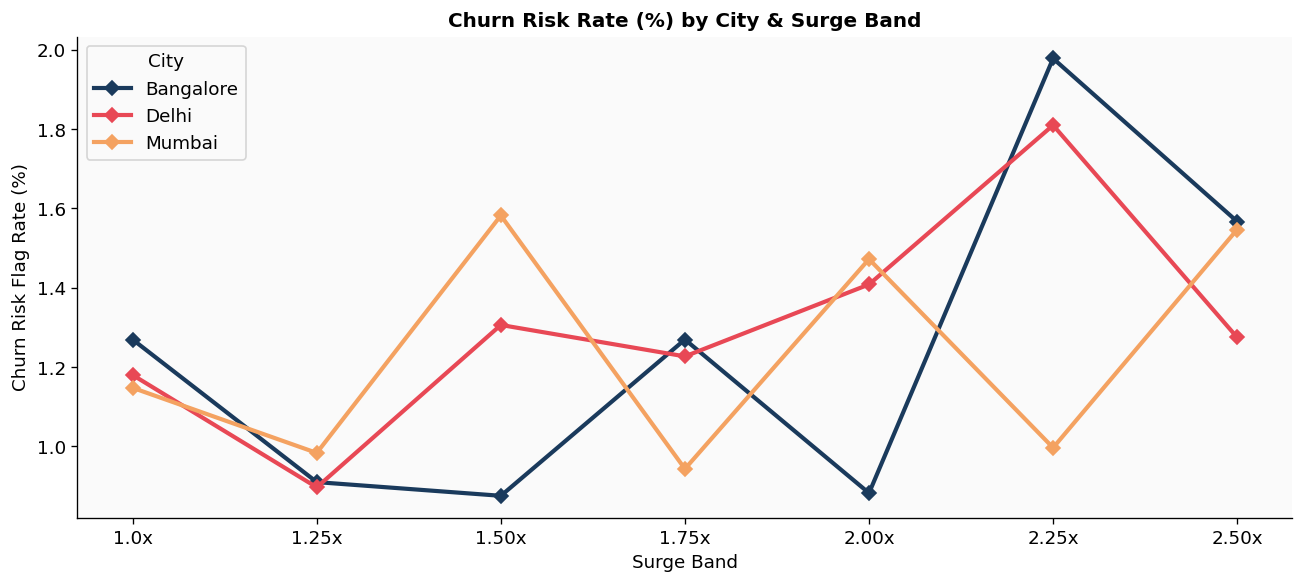

In [36]:
churn_city = (
    df.groupby(['city','surge_band'])['churn_risk_flag']
      .mean().reset_index()
      .pivot(index='city', columns='surge_band', values='churn_risk_flag')
      .reindex(columns=SURGE_ORDER) * 100
)

fig, ax = plt.subplots(figsize=(11,5))
city_colors = [PALETTE['primary'], PALETTE['accent'], PALETTE['gold']]
for i, city in enumerate(churn_city.index):
    ax.plot(SURGE_ORDER, churn_city.loc[city], marker='D',
            color=city_colors[i], linewidth=2.5, label=city)
ax.set_title('Churn Risk Rate (%) by City & Surge Band',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Surge Band'); ax.set_ylabel('Churn Risk Flag Rate (%)')
ax.legend(title='City')
plt.tight_layout()
plt.savefig('fig4_churn_city_surge.png', bbox_inches='tight', dpi=150)
plt.show()


### Business Interpretation¶

Churn risk increases at higher surge levels across all cities, indicating growing customer attrition risk under aggressive pricing conditions. Bangalore shows the sharpest increase at extreme surge levels, while Delhi and Mumbai also exhibit elevated churn indicators. This suggests that excessive surge pricing may negatively impact long-term customer retention.

### Demand Volume by Surge Band

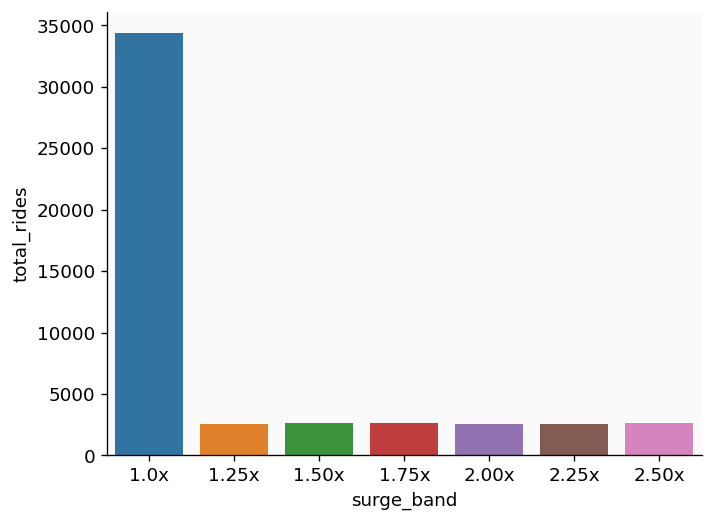

In [41]:
demand_analysis = (
    df.groupby('surge_band')
    .agg(total_rides=('trip_id','count'))
    .reset_index()
)

sns.barplot(data=demand_analysis,
            x='surge_band',
            y='total_rides')
plt.savefig('total_rides.png', bbox_inches='tight', dpi=150)

### Business Interpretation

Most rides occur under low surge conditions, while demand volume declines significantly at higher surge bands. This suggests that customers are more likely to complete rides under moderate pricing conditions, whereas aggressive surge pricing may suppress demand and reduce ride activity.

### Avg Fare by Surge Band

<Axes: xlabel='avg_fare', ylabel='cancellation_rate'>

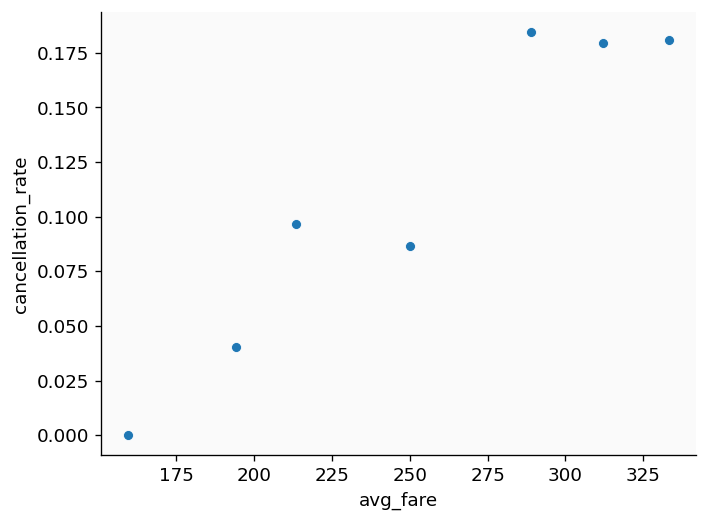

In [38]:
fare_analysis = (
    df.groupby('surge_band')
    .agg(
        avg_fare=('fare_inr','mean'),
        cancellation_rate=('cancelled','mean')
    )
)
sns.scatterplot(
    data=fare_analysis,
    x='avg_fare',
    y='cancellation_rate'
)

### Business Interpretation

Cancellation rates increase as average fare levels rise, indicating growing customer price sensitivity under higher surge conditions. The sharp increase in cancellations at premium fare levels suggests that aggressive pricing may discourage ride completion and negatively affect customer retention.

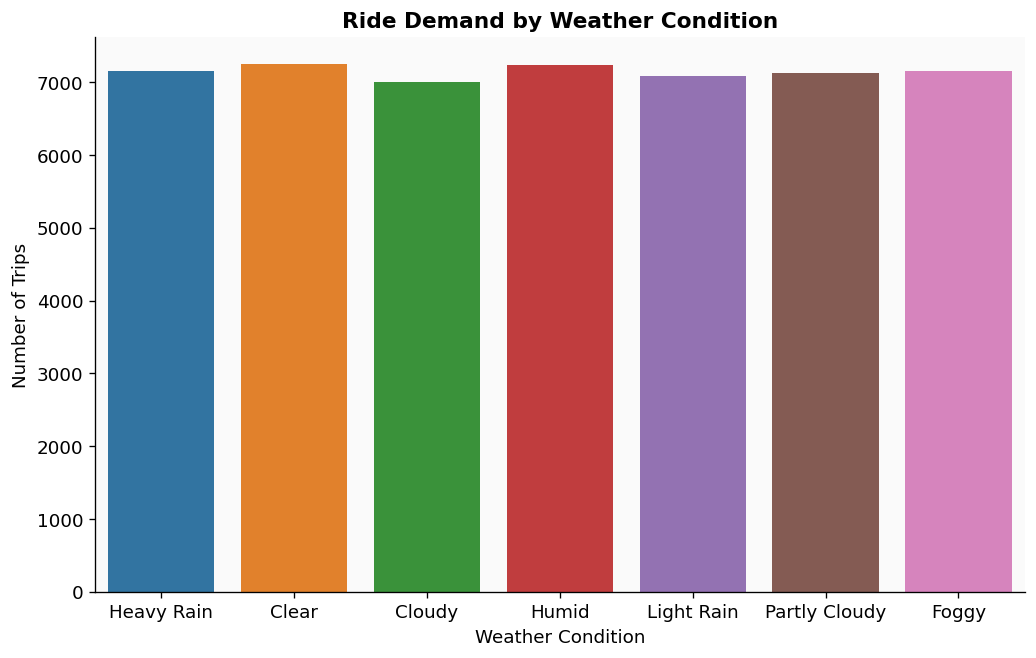

In [39]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='weather_condition'
)

plt.title("Ride Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Trips")


plt.show()

### Business Interpretation¶

Ride demand remains relatively stable across different weather conditions, with only minor variations in trip volume. This suggests that weather has a limited impact on overall ride demand, although adverse conditions may still contribute to operational challenges and surge pricing during peak periods.

In [40]:
executive_summary = (
    df.groupby('surge_band')
    .agg(
        Total_Trips=('trip_id', 'count'),
        Completion_Rate=('ride_completed', 'mean'),
        Cancellation_Rate=('cancelled', 'mean'),
        Avg_Satisfaction=('satisfaction_score', 'mean'),
        Churn_Risk_Rate=('churn_risk_flag', 'mean'),
        Avg_Fare=('fare_inr', 'mean')
    )
    .reset_index()
)

# Convert rates into percentages
executive_summary['Completion_Rate'] = executive_summary['Completion_Rate'] * 100
executive_summary['Cancellation_Rate'] = executive_summary['Cancellation_Rate'] * 100
executive_summary['Churn_Risk_Rate'] = executive_summary['Churn_Risk_Rate'] * 100

# Round values for presentation
executive_summary = executive_summary.round({
    'Completion_Rate': 1,
    'Cancellation_Rate': 1,
    'Avg_Satisfaction': 2,
    'Churn_Risk_Rate': 2,
    'Avg_Fare': 2
})

# Rename columns for cleaner presentation
executive_summary.columns = [
    'Surge Band',
    'Total Trips',
    'Completion Rate (%)',
    'Cancellation Rate (%)',
    'Avg Satisfaction',
    'Churn Risk Rate (%)',
    'Avg Fare'
]

# Display table
print("\n EXECUTIVE SUMMARY TABLE:\n")
display(executive_summary)


 EXECUTIVE SUMMARY TABLE:



,Surge Band,Total Trips,Completion Rate (%),Cancellation Rate (%),Avg Satisfaction,Churn Risk Rate (%),Avg Fare
0,1.0x,34381,100.0,0.0,4.14,1.20,159.46
1,1.25x,2573,96.0,4.0,3.82,0.93,194.14
2,1.50x,2665,90.4,9.6,3.49,1.24,213.49
3,1.75x,2630,91.3,8.7,3.18,1.14,249.96
4,2.00x,2542,81.5,18.5,2.82,1.22,288.97
5,2.25x,2577,82.1,17.9,2.51,1.59,312.23
6,2.50x,2632,81.9,18.1,2.22,1.48,333.32


### Executive Summary Interpretation

The analysis shows that customer behaviour deteriorates consistently as surge intensity increases. While average fares rise significantly under higher surge bands, completion rates decline and cancellation rates increase sharply beyond the 1.75x–2.0x range. Customer satisfaction also drops steadily from 4.14 at baseline pricing to 2.22 at extreme surge levels, while churn risk indicators increase at higher surge multipliers. Overall, the findings suggest that aggressive surge pricing may improve short-term revenue but can negatively impact customer experience, ride completion, and long-term retention.